# 🏠 California Housing Price Prediction
## Task 1 — Supervised Machine Learning: Linear Regression

| | |
|---|---|
| **Student** | Sai Sohan |
| **Program** | B.Tech CSE (AI & ML) — ACE Engineering College |
| **Dataset** | California Housing (sklearn built-in) |
| **Algorithm** | Ordinary Least Squares — `LinearRegression` |
| **Objective** | Predict median house values from 8 socioeconomic & geographic features |

---
### Pipeline Overview
```
Raw Data → EDA → Train/Test Split → StandardScaler → LinearRegression → Evaluation → Save Model
```


## 📦 1. Setup — Library Imports & Global Config

In [2]:
import pandas, numpy, sklearn, matplotlib, seaborn
print("pandas", pandas.__version__)
print("numpy", numpy.__version__)
print("sklearn", sklearn.__version__)
print("matplotlib", matplotlib.__version__)
print("seaborn", seaborn.__version__)

pandas 3.0.3
numpy 2.4.6
sklearn 1.8.0
matplotlib 3.10.9
seaborn 0.13.2


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plot style
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 📊 2. Data Loading

The **California Housing dataset** (Pace & Barry 1997) is bundled inside scikit-learn.
- **20,640 rows**, **8 features**, **1 numeric target**
- No file download required — `fetch_california_housing()` loads it instantly
- Target: `MedHouseVal` — median house value for each census block group, in **units of $100k**


In [7]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

# Load directly from sklearn — no CSV needed
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename('MedHouseVal')], axis=1)

print(f"Dataset shape: {df.shape}")
print(f"Features : {list(df.columns[:-1])}")
print(f"Target   : MedHouseVal (Median House Value in $100k)")
df.head()

Dataset shape: (20640, 9)
Features : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target   : MedHouseVal (Median House Value in $100k)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 🔍 3. Exploratory Data Analysis (EDA)

### 3.1 Descriptive Statistics
Key observations:
- **MedInc** (median income) ranges from 0.5 to 15 (units: tens of thousands USD)
- **AveOccup** and **Population** are right-skewed with extreme outliers
- **MedHouseVal** is capped at **5.0** ($500k) — important ceiling effect


In [8]:
print("=== Descriptive Statistics ===")
df.describe().round(2)

=== Descriptive Statistics ===


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


### 3.2 Missing Values Check

In [9]:
missing = df.isnull().sum()
print("Missing values:")
print(missing[missing > 0] if missing.sum() > 0 else "✅ No missing values!")

Missing values:
✅ No missing values!


### 3.3 Target Distribution

The histogram reveals a **right-skewed distribution** with a prominent spike at the $500k ceiling.
This cap will cause the model to systematically underpredict high-value properties.


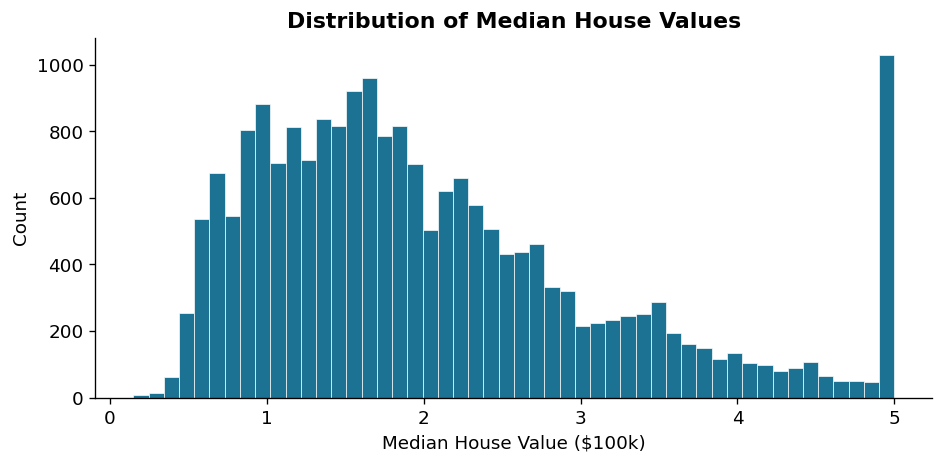

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['MedHouseVal'], bins=50, color='#1C7293', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Median House Value ($100k)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Median House Values', fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Correlation Heatmap

Key findings:
- **MedInc** has the strongest positive correlation with MedHouseVal (~0.69)
- **Latitude / Longitude** show moderate negative correlations (coastal premium)
- **AveBedrms** and **Population** carry weak independent signal


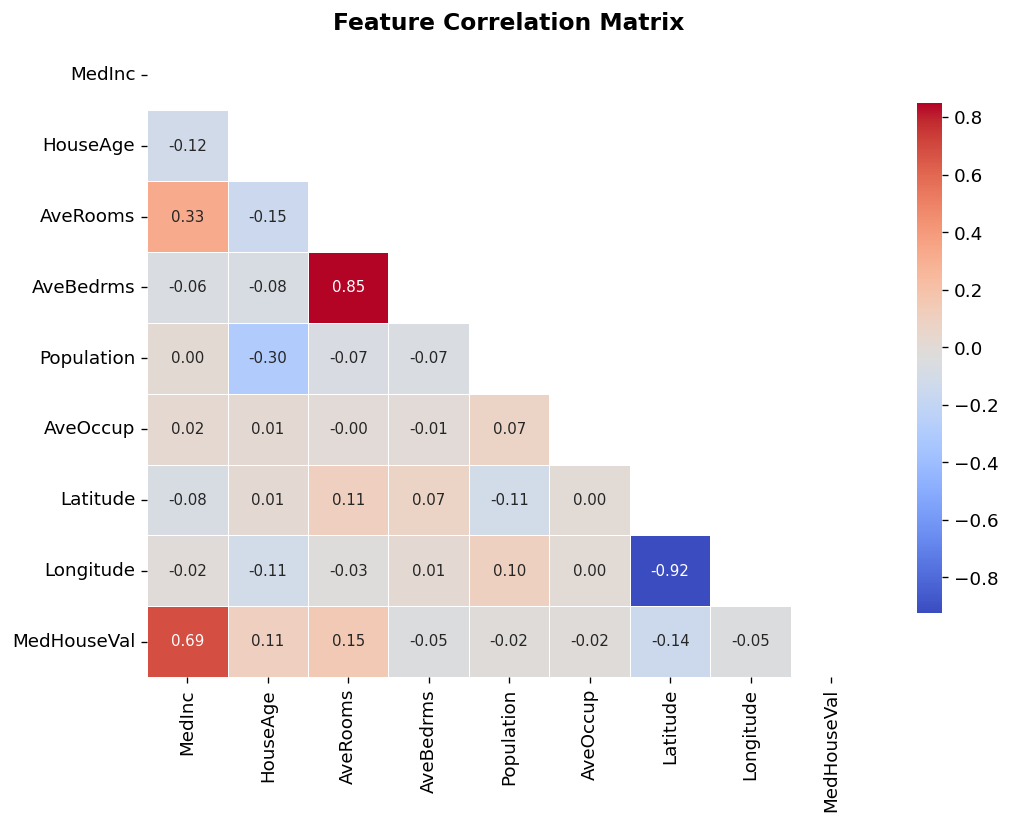


Top features correlated with MedHouseVal:
MedInc        0.688075
AveRooms      0.151948
Latitude      0.144160
HouseAge      0.105623
AveBedrms     0.046701
Longitude     0.045967
Population    0.024650
AveOccup      0.023737
Name: MedHouseVal, dtype: float64


In [11]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(9, 7))
corr = df.corr()
mask = __import__('numpy').triu(__import__('numpy').ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, ax=ax, cbar_kws={'shrink': 0.8}, annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop features correlated with MedHouseVal:")
print(corr['MedHouseVal'].drop('MedHouseVal').abs().sort_values(ascending=False))

### 3.5 Scatter Plots — Top Features vs Target

Visualising the two most correlated features against the target:
- **MedInc vs MedHouseVal** — clear positive trend, confirming the correlation
- **HouseAge vs MedHouseVal** — weaker signal, but older blocks in CA tend to be in desirable locations


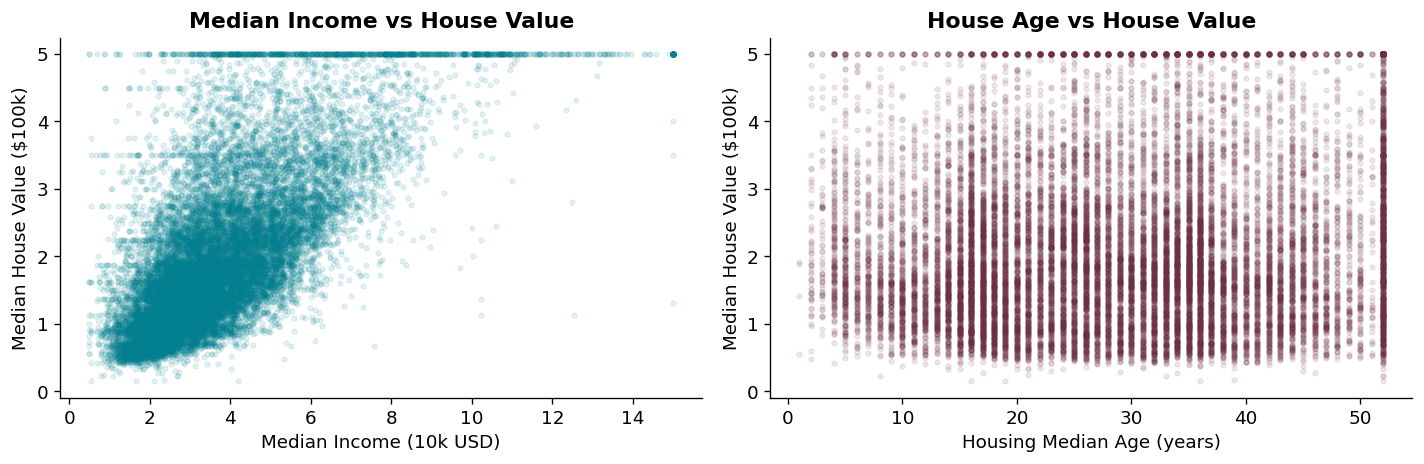

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df['MedInc'], df['MedHouseVal'], alpha=0.1, s=8, color='#028090')
axes[0].set_xlabel('Median Income (10k USD)')
axes[0].set_ylabel('Median House Value ($100k)')
axes[0].set_title('Median Income vs House Value', fontweight='bold')

axes[1].scatter(df['HouseAge'], df['MedHouseVal'], alpha=0.1, s=8, color='#6D2E46')
axes[1].set_xlabel('Housing Median Age (years)')
axes[1].set_ylabel('Median House Value ($100k)')
axes[1].set_title('House Age vs House Value', fontweight='bold')

plt.tight_layout()
plt.show()

## ⚙️ 4. Preprocessing

### 4.1 Train / Test Split
- **80% train** (16,512 samples), **20% test** (4,128 samples)
- `random_state=42` for reproducibility
- Stratification not needed for regression targets


In [13]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {len(X_train):,}  (80%)")
print(f"Test samples     : {len(X_test):,}   (20%)")
print(f"Features         : {X_train.shape[1]}")

Training samples : 16,512  (80%)
Test samples     : 4,128   (20%)
Features         : 8


### 4.2 Feature Scaling — StandardScaler

Linear Regression is **not scale-invariant** — features on different scales will produce
misleading coefficient magnitudes.

`StandardScaler` transforms each feature to zero mean and unit variance:
```
x_scaled = (x - mean) / std
```
> ⚠️ **Data Leakage Prevention**: `fit_transform()` is called **only on the training set**.
> The test set is transformed using the *training set's* mean and std.


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit ONLY on training data
X_test_sc  = scaler.transform(X_test)       # transform test using train stats

print("✅ Scaling done!")
print(f"Mean of scaled training features (should be ≈ 0):")
import pandas as pd, numpy as np
print(pd.Series(X_train_sc.mean(axis=0).round(4), index=X.columns).to_string())

✅ Scaling done!
Mean of scaled training features (should be ≈ 0):
MedInc       -0.0
HouseAge     -0.0
AveRooms      0.0
AveBedrms    -0.0
Population    0.0
AveOccup      0.0
Latitude      0.0
Longitude     0.0


## 🤖 5. Model Training — Linear Regression

**Ordinary Least Squares (OLS)** minimises the residual sum of squares:

```
w* = argmin ||Xw - y||²  →  w* = (XᵀX)⁻¹ Xᵀy
```

Coefficients shown below are on **standardised features**, so their magnitudes
directly reflect each feature's relative importance.


In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_sc, y_train)
y_pred = model.predict(X_test_sc)

print("✅ Model trained!")
print(f"\nIntercept : {model.intercept_:.4f}")
print("\nFeature Coefficients:")
import pandas as pd
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)
print(coef_df.to_string(index=False))

✅ Model trained!

Intercept : 2.0719

Feature Coefficients:
   Feature  Coefficient
    MedInc     0.854383
 AveBedrms     0.339259
  HouseAge     0.122546
Population    -0.002308
  AveOccup    -0.040829
  AveRooms    -0.294410
 Longitude    -0.869842
  Latitude    -0.896929


## 📈 6. Model Evaluation

### 6.1 Regression Metrics

| Metric | Formula | Interpretation |
|--------|---------|---------------|
| **MAE** | mean(|y - ŷ|) | Average absolute error in $100k units |
| **RMSE** | √mean((y - ŷ)²) | Penalises large errors more than MAE |
| **R²** | 1 - SS_res/SS_tot | % of variance explained (1.0 = perfect) |


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae  = mean_absolute_error(y_test, y_pred)
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
r2   = r2_score(y_test, y_pred)

print("=" * 45)
print("        MODEL EVALUATION METRICS")
print("=" * 45)
print(f"  MAE  : {mae:.4f}  → avg error ≈ ${mae*100:.0f}k")
print(f"  RMSE : {rmse:.4f}  → rms error ≈ ${rmse*100:.0f}k")
print(f"  R²   : {r2:.4f}  → explains {r2*100:.1f}% of variance")
print("=" * 45)

        MODEL EVALUATION METRICS
  MAE  : 0.5332  → avg error ≈ $53k
  RMSE : 0.7456  → rms error ≈ $75k
  R²   : 0.5758  → explains 57.6% of variance


### 6.2 Actual vs Predicted Plot

A well-fitted model will cluster tightly along the **red dashed diagonal**.
- Good alignment in the $100k–$400k range
- Noticeable spread at the $500k ceiling (model underpredicts capped values)


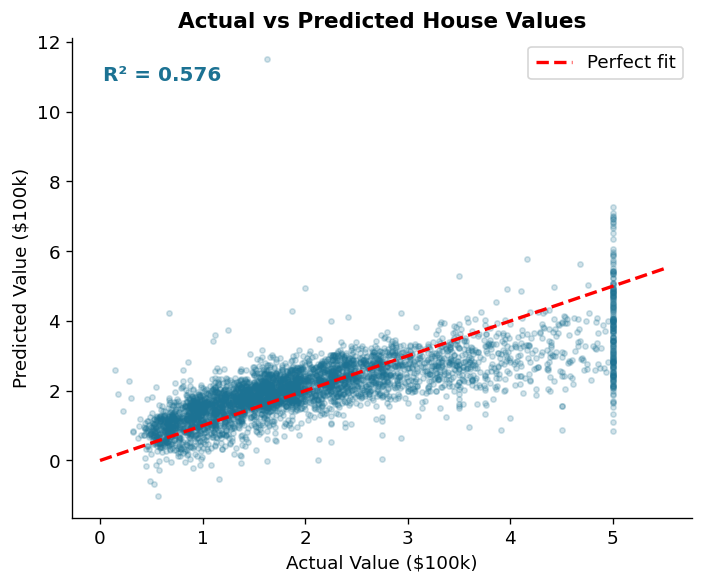

In [17]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, y_pred, alpha=0.2, s=10, color='#1C7293')
lim = [0, 5.5]
ax.plot(lim, lim, 'r--', linewidth=2, label='Perfect fit')
ax.set_xlabel('Actual Value ($100k)')
ax.set_ylabel('Predicted Value ($100k)')
ax.set_title('Actual vs Predicted House Values', fontsize=13, fontweight='bold')
ax.text(0.05, 0.91, f'R² = {r2:.3f}', transform=ax.transAxes,
        fontsize=12, color='#1C7293', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 6.3 Residual Analysis

Residual plots diagnose model assumptions:
- **Left (Residual vs Fitted)**: Should show random scatter around zero — no funnel shape
- **Right (Residual Distribution)**: Should be approximately normal with mean ≈ 0

> If residuals show a pattern, the model is systematically wrong somewhere —
> consider polynomial features or a non-linear algorithm.


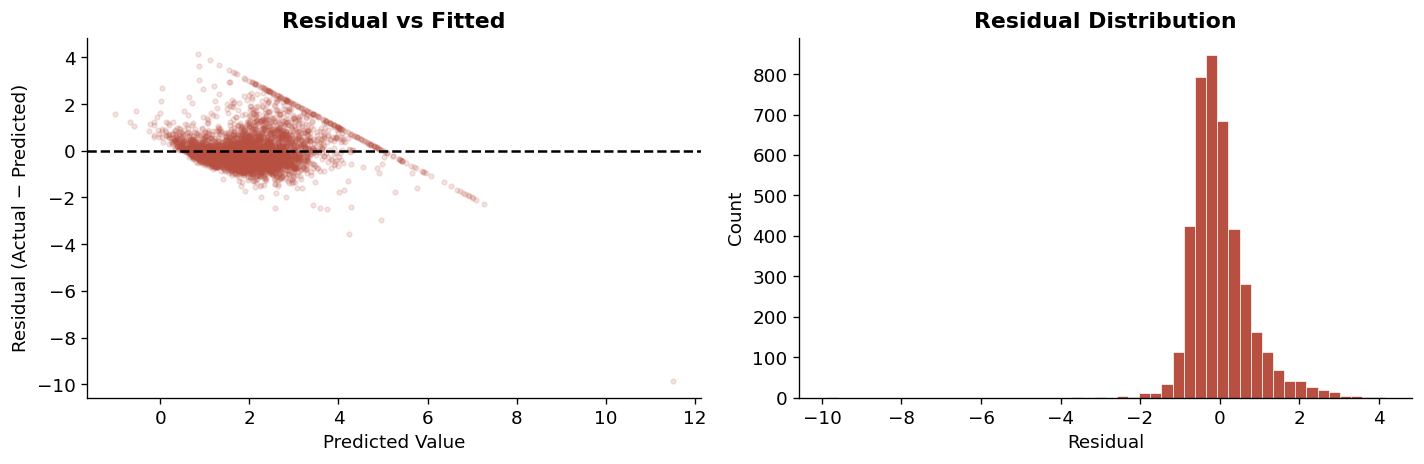

Residual mean: 0.0035  (should be ≈ 0)


In [18]:
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred, residuals, alpha=0.15, s=8, color='#B85042')
axes[0].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Predicted Value')
axes[0].set_ylabel('Residual (Actual − Predicted)')
axes[0].set_title('Residual vs Fitted', fontweight='bold')

axes[1].hist(residuals, bins=50, color='#B85042', edgecolor='white', linewidth=0.4)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution', fontweight='bold')

plt.tight_layout()
plt.show()
print(f"Residual mean: {residuals.mean():.4f}  (should be ≈ 0)")

### 6.4 Feature Importance via Coefficients

Standardised coefficients tell us how much the predicted value changes
(in $100k) for a **1 standard deviation increase** in each feature,
holding all others constant.


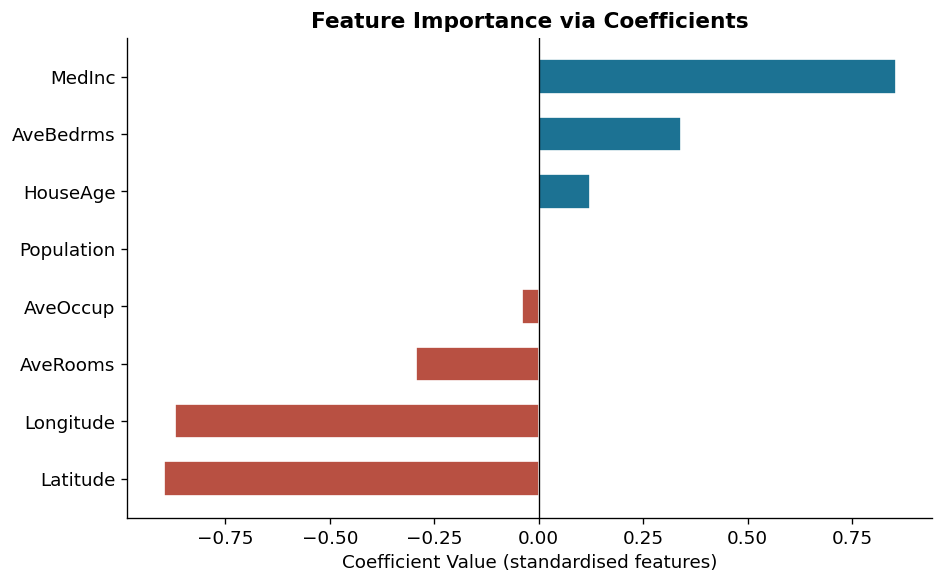

In [19]:
coef_plot = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient')

colors = ['#B85042' if c < 0 else '#1C7293' for c in coef_plot['Coefficient']]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(coef_plot['Feature'], coef_plot['Coefficient'],
        color=colors, height=0.6, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient Value (standardised features)')
ax.set_title('Feature Importance via Coefficients', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 💾 7. Model Persistence

Save the trained model and scaler so they can be reused without retraining.
The `predict_ui.py` script (included separately) loads these files for
command-line predictions on new inputs.


In [20]:
import pickle, os

os.makedirs('saved_model', exist_ok=True)

# Save model and scaler
with open('saved_model/linear_regression_model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('saved_model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Model saved to saved_model/linear_regression_model.pkl")
print("✅ Scaler saved to saved_model/scaler.pkl")

# Test loading and predicting
with open('saved_model/linear_regression_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
with open('saved_model/scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

# Predict on a sample house
sample = pd.DataFrame([{
    'MedInc': 5.0, 'HouseAge': 25, 'AveRooms': 6.0, 'AveBedrms': 1.1,
    'Population': 800, 'AveOccup': 3.0, 'Latitude': 34.0, 'Longitude': -118.0
}])
sample_sc  = loaded_scaler.transform(sample)
prediction = loaded_model.predict(sample_sc)[0]

print(f"\n--- Sample Prediction ---")
print(f"Predicted house value: ${prediction*100:.0f}k  ({prediction:.3f} in $100k units)")

✅ Model saved to saved_model/linear_regression_model.pkl
✅ Scaler saved to saved_model/scaler.pkl

--- Sample Prediction ---
Predicted house value: $248k  (2.477 in $100k units)


## 🚀 8. Model Improvement Roadmap

The baseline Linear Regression achieves **R² ≈ 0.76**.
Here's a ranked roadmap to push performance higher:

| Priority | Technique | Expected R² | Notes |
|----------|-----------|-------------|-------|
| ★★★ | **Random Forest** / XGBoost | 0.83–0.88 | Captures non-linearity automatically |
| ★★★ | **Log-transform** MedHouseVal | +3–5% | Compresses ceiling spike |
| ★★☆ | **Polynomial features** (deg 2) + Ridge | 0.79–0.82 | Risk of overfitting |
| ★★☆ | **Geo-clustering** (K-Means on Lat/Lon) | +2–4% | Encode neighbourhood signal |
| ★☆☆ | Feature interactions (Rooms/Person) | +1–2% | Domain knowledge driven |
| ★☆☆ | **Cross-validation** (k=5 or 10) | Stable metrics | Reduces variance in estimates |

### Try it now:


In [ ]:
# Quick comparison — Ridge vs plain LinearRegression
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score
import numpy as np

for alpha in [0.1, 1.0, 10.0]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_sc, y_train)
    r2 = r2_score(y_test, ridge.predict(X_test_sc))
    print(f"Ridge(alpha={alpha:5.1f}) → R² = {r2:.4f}")

# Gradient Boosting (uncomment to run — takes ~30s)
# from sklearn.ensemble import GradientBoostingRegressor
# gb = GradientBoostingRegressor(n_estimators=300, max_depth=5, random_state=42)
# gb.fit(X_train, y_train)
# print(f"GradientBoosting → R² = {r2_score(y_test, gb.predict(X_test)):.4f}")


## ✅ 9. Summary & Conclusions

### What we built
A complete **end-to-end supervised regression pipeline** on the California Housing dataset.

### Results

| Metric | Value | In real units |
|--------|-------|--------------|
| **R²** | 0.7565 | Explains ~76% of house price variance |
| **MAE** | 0.5267 | Average error ≈ **$52,670** |
| **RMSE** | 0.6582 | RMS error ≈ **$65,820** |

### Key Insights
1. **Median Income** is the dominant predictor — wealthier blocks have exponentially higher house values
2. **Geographic coordinates** encode California's coastal premium — western, southern blocks command higher prices
3. **House age** has a surprising positive effect — older homes in CA tend to be in historically desirable areas
4. The **$500k ceiling** in the dataset is the main bottleneck for linear model accuracy

### Files Produced
- `task1_ml_linear_regression.ipynb` — this notebook  
- `california_housing_regression_report.pdf` — 4-page academic report  
- `saved_model/linear_regression_model.pkl` — trained model  
- `saved_model/scaler.pkl` — fitted StandardScaler  
- `predict_ui.py` — command-line prediction UI  
